# <font color='green'> **MODELISATION DE L'ABSENCE DE POURBOIRE CHEZ LES CHAUFFEURS DE TAXI DE NEW YORK** </font>

![Image](https://media.lematin.ch/4/image/2023/11/10/51338278-59cd-4559-af66-8efbac423112.jpeg?auto=format%2Ccompress%2Cenhance&fit=max&w=1200&h=1200&rect=0%2C0%2C1024%2C683&s=7864704c0ca9395afa830274aeb70f2e)

# Contexte
Le projet porte sur la modélisation de la **générosité des clients** des taxis new-yorkais à partir de données de trajets.  
Il sera question pour nous dans ce projet de construire un modèle capable de prédire si un client **est_généreux** ou non, en se basant sur des variables telles que la durée du trajet, la distance, ou encore l’heure de la course...

Il aurait pu être question  pour nous de prédire si un client laissera un pourboire ou non, mais étant donné la problématique y relative, on se contentera de classifier un client de généreux ou non à partir de ses données

---

## Objectif
Prédire si un client sera classé **est_généreux** (donnera un pourboire supérieur ou égale à 20% du montant de la course) ou non, à partir des données de trajets de taxi à New York.

---

## Structure du Projet

### I. Chargement du Dataset

- Importation des bibliothèques nécessaires 
- Importation et fusion des deux parties du jeu de données 
- Création de la **target** binaire (ex: `Generous = tip_amount > 20%Total_amount`)

---

### II. Séparation du Dataset
- Séparation en deux sous-ensembles :
  - `Train set`
  - `Test set`
- (Utilisation de `train_test_split` de `sklearn`)

---

### III. Analyse exploratoire (EDA)
- Data understanding
- types de données
- Visualisation des distributions des variables:
  * Numériques
  * Catégorielles
- Analyse des dOutliers
- Analyse bivariée entre la target et les autres features
- Visualisation de la correlatione entre les variables numériques

---

### IV. Prétraitement
- Nettoyage des données (valeurs manquantes, types, outliers)
- Feature Engineering :
  - Création de variables à partir de la date/heure
- Encodage des variables catégorielles
- Standardisation / Normalisation si nécessaire

---

### V. Sélection et évaluation des modèles (Validation croisée)
- Mise en place d'une **Grid Search** avec **Validation Croisée**
- Entraînement et comparaison de plusieurs modèles :
  - KNN
  - Random Forest
  - Gradient Boosting
  - etc.
- Sélection des meilleurs hyperparamètres

---

### VI. Ré-entraînement final du modèle
- Entraînement sur **tout le Train Set** avec les meilleurs hyperparamètres

---

### VII. Évaluation sur le Test Set
- Prédictions finales
- Mesures de performance :
  - Accuracy, Precision, Recall, F1-Score
  - Matrice de confusion
  - ROC-AUC

---

### VIII. Conclusion & pistes d'amélioration
- Interprétation des résultats
- Analyse des erreurs
- Possibilités d'amélioration (plus de données, autres features, tuning...)



# <font color='brown'> I. CHARGEMENT DU DATASET </font>

In [3]:
# Manipulation de données
import pandas as pd
import numpy as np
import copy

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Prétraitement
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Pour le feature engineering (extraction de date, heure, etc.)
from datetime import datetime

In [4]:
## **Chargement et fusion des deux parties du dataset**
d1=pd.read_csv('2017_Yellow_Taxi_Trip_Data.csv')
d2=pd.read_csv('nyc_preds_means.csv')

data=pd.concat([d1,d2], axis=1)
data=pd.DataFrame(data)
data

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,mean_duration,mean_distance,predicted_fare
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,...,13.0,0.0,0.5,2.76,0.00,0.3,16.56,22.847222,3.521667,16.434245
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,...,16.0,0.0,0.5,4.00,0.00,0.3,20.80,24.470370,3.108889,16.052218
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,...,6.5,0.0,0.5,1.45,0.00,0.3,8.75,7.250000,0.881429,7.053706
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,...,20.5,0.0,0.5,6.39,0.00,0.3,27.69,30.250000,3.700000,18.731650
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,...,16.5,0.5,0.5,0.00,0.00,0.3,17.80,14.616667,4.435000,15.845642
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22694,14873857,2,02/24/2017 5:37:23 PM,02/24/2017 5:40:39 PM,3,0.61,1,N,48,186,...,4.0,1.0,0.5,0.00,0.00,0.3,5.80,8.594643,1.098214,7.799138
22695,66632549,2,08/06/2017 4:43:59 PM,08/06/2017 5:24:47 PM,1,16.71,2,N,132,164,...,52.0,0.0,0.5,14.64,5.76,0.3,73.20,59.560417,18.757500,52.000000
22696,74239933,2,09/04/2017 2:54:14 PM,09/04/2017 2:58:22 PM,1,0.42,1,N,107,234,...,4.5,0.0,0.5,0.00,0.00,0.3,5.30,6.609091,0.684242,6.130896
22697,60217333,2,07/15/2017 12:56:30 PM,07/15/2017 1:08:26 PM,1,2.36,1,N,68,144,...,10.5,0.0,0.5,1.70,0.00,0.3,13.00,16.650000,2.077500,11.707049


In [5]:
#Création d'une copy du jeu de données
df=copy.deepcopy(data)

#Traduction de ses colonnes en français
# Dictionnaire de traduction 
column_translation = {
    "Unnamed: 0": "ID",
    "VendorID": "ID_ven",
    "tpep_pickup_datetime": "dt_départ",
    "tpep_dropoff_datetime": "dt_arrivée",
    "passenger_count": "nb_pass",
    "trip_distance": "dist_trajet",
    "RatecodeID": "code_tarif",
    "store_and_fwd_flag": "données_différé",
    "PULocationID": "ID_dep",
    "DOLocationID": "ID_arr",
    "payment_type": "type_paie",
    "fare_amount": "montant_course",
    "extra": "supplément",
    "mta_tax": "taxe_mta",
    "tip_amount": "pourboire",
    "tolls_amount": "péages",
    "improvement_surcharge": "suppl_amélioration",
    "total_amount": "montant_total",
    "mean_duration": "duree_moy",
    "mean_distance": "dist_moy",
    "predicted_fare": "tarif_prédit"
}

# Application du renommage
df.rename(columns=column_translation, inplace=True)

#Vérifie le résultat
print(df.columns)

Index(['ID', 'ID_ven', 'dt_départ', 'dt_arrivée', 'nb_pass', 'dist_trajet',
       'code_tarif', 'données_différé', 'ID_dep', 'ID_arr', 'type_paie',
       'montant_course', 'supplément', 'taxe_mta', 'pourboire', 'péages',
       'suppl_amélioration', 'montant_total', 'duree_moy', 'dist_moy',
       'tarif_prédit'],
      dtype='object')


In [6]:
# Création de la colonne 'client_genereux' qui est notre target
df['client_genereux'] = (df['pourboire'] >= 0.2 * df['montant_course']).astype(int)

# Suppression des colonnes originales 'pourboire' et 'montant_total' pour éviter le "trucage"
df= df.drop(columns=['pourboire', 'montant_course'])

# Vérifier le résultat
df.head()

,ID,ID_ven,dt_départ,dt_arrivée,nb_pass,dist_trajet,code_tarif,données_différé,ID_dep,ID_arr,type_paie,supplément,taxe_mta,péages,suppl_amélioration,montant_total,duree_moy,dist_moy,tarif_prédit,client_genereux
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,0.0,0.5,0.0,0.3,16.56,22.847222,3.521667,16.434245,1
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,0.0,0.5,0.0,0.3,20.80,24.470370,3.108889,16.052218,1
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,0.0,0.5,0.0,0.3,8.75,7.250000,0.881429,7.053706,1
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,0.0,0.5,0.0,0.3,27.69,30.250000,3.700000,18.731650,1
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,0.5,0.5,0.0,0.3,17.80,14.616667,4.435000,15.845642,0


# <font color="brown"> II. SEPARATION DU DATASET </font>

In [8]:
# Définir X (features) et y (target)
X = df.drop(columns=['client_genereux'])
y = df['client_genereux']

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% test, 80% train
    random_state=42,     # pour reproductibilité
)

In [9]:
print(f'Dimensions de X_train: {X_train.shape}')

print(f'Dimensions de y_train: {y_train.shape}')



print(f'Dimensions de X_test: {X_test.shape}')

print(f'Dimensions de y_test: {y_test.shape}')





Dimensions de X_train: (18159, 19)
Dimensions de y_train: (18159,)
Dimensions de X_test: (4540, 19)
Dimensions de y_test: (4540,)


In [10]:
y_train.value_counts()

client_genereux
0    9286
1    8873
Name: count, dtype: int64

# <font color='brown'>III. ANALYSE EXPLORATOIRE DE DONNEES (EDA) </font>

In [12]:
#La target
y_train.isnull().sum()

0

**Interpretation:** Elle ne contient pas de valeurs manquante

In [14]:
y_train.value_counts(normalize=True)*100

client_genereux
0    51.137177
1    48.862823
Name: proportion, dtype: float64

**Interpretation:** Notre target est assez équilibré

In [16]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18159 entries, 9688 to 15795
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  18159 non-null  int64  
 1   ID_ven              18159 non-null  int64  
 2   dt_départ           18159 non-null  object 
 3   dt_arrivée          18159 non-null  object 
 4   nb_pass             18159 non-null  int64  
 5   dist_trajet         18159 non-null  float64
 6   code_tarif          18159 non-null  int64  
 7   données_différé     18159 non-null  object 
 8   ID_dep              18159 non-null  int64  
 9   ID_arr              18159 non-null  int64  
 10  type_paie           18159 non-null  int64  
 11  supplément          18159 non-null  float64
 12  taxe_mta            18159 non-null  float64
 13  péages              18159 non-null  float64
 14  suppl_amélioration  18159 non-null  float64
 15  montant_total       18159 non-null  float64
 16  duree_

In [17]:
X_train.describe()

,ID,ID_ven,nb_pass,dist_trajet,code_tarif,ID_dep,ID_arr,type_paie,supplément,taxe_mta,péages,suppl_amélioration,montant_total,duree_moy,dist_moy,tarif_prédit
count,1.815900e+04,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000
mean,5.676729e+07,1.554821,1.638141,2.941697,1.045322,162.906658,161.223360,1.338565,0.335867,0.497494,0.320110,0.299554,16.356230,14.577215,2.940057,13.066561
std,3.275347e+07,0.496999,1.279379,3.704203,0.779660,66.459306,70.127128,0.497073,0.465464,0.039012,1.423153,0.015578,14.244742,10.206936,3.601354,9.815325
min,1.212700e+04,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,-0.500000,0.000000,-0.300000,-120.300000,0.000000,0.000000,2.934494
25%,2.846758e+07,1.000000,1.000000,1.000000,1.000000,114.000000,112.000000,1.000000,0.000000,0.500000,0.000000,0.300000,8.750000,8.055128,1.011622,7.404093
50%,5.670583e+07,2.000000,1.000000,1.610000,1.000000,162.000000,162.000000,1.000000,0.000000,0.500000,0.000000,0.300000,11.800000,11.608333,1.622857,9.588526
75%,8.547173e+07,2.000000,2.000000,3.100000,1.000000,233.000000,233.000000,2.000000,0.500000,0.500000,0.000000,0.300000,17.800000,17.405556,3.146667,13.993952
max,1.134863e+08,2.000000,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,4.500000,0.500000,19.100000,0.300000,450.300000,88.783333,33.920000,89.171050


In [18]:
X_train.dtypes.value_counts()

float64    9
int64      7
object     3
Name: count, dtype: int64

<Axes: ylabel='count'>

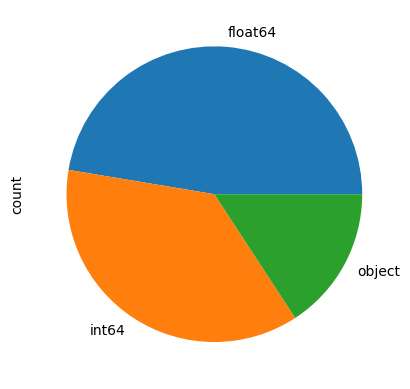

In [19]:
X_train.dtypes.value_counts().plot.pie()

In [20]:
# Valeurs manquantes
X_train.isnull().sum()


ID                    0
ID_ven                0
dt_départ             0
dt_arrivée            0
nb_pass               0
dist_trajet           0
code_tarif            0
données_différé       0
ID_dep                0
ID_arr                0
type_paie             0
supplément            0
taxe_mta              0
péages                0
suppl_amélioration    0
montant_total         0
duree_moy             0
dist_moy              0
tarif_prédit          0
dtype: int64

**Interpretation:** On remarque six missing values dans la colonne que nous 'ratio_tip/amount'

<Axes: >

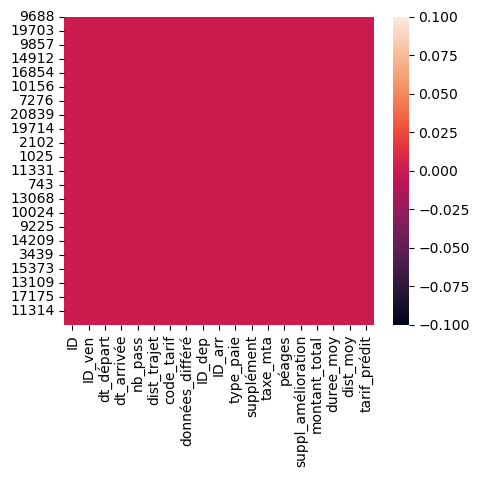

In [22]:
# Set the figure size
plt.figure(figsize=(5, 4))  

# Create a heatmap to visualize missing values
sns.heatmap(X_train.isna() , cbar=True) 

 **Interpretation**:
Le dataset est complet et ne contient presque aucune valeur manquante

In [32]:
#Séparation des variables catégorielles et des variables numériques

num_col=X_train.select_dtypes(include=['int', 'float']).columns
cat_col=X_train.select_dtypes(include=['object']).columns

print(f'Les colonnes numériques sont: {list(num_col)}')
print ('\n')
print(f'Les colonnes catégorielles sont: {list(cat_col)}')

Les colonnes numériques sont: ['ID', 'ID_ven', 'nb_pass', 'dist_trajet', 'code_tarif', 'ID_dep', 'ID_arr', 'type_paie', 'supplément', 'taxe_mta', 'péages', 'suppl_amélioration', 'montant_total', 'duree_moy', 'dist_moy', 'tarif_prédit']


Les colonnes catégorielles sont: ['dt_départ', 'dt_arrivée', 'données_différé']


### 1) Analyse Multivariée

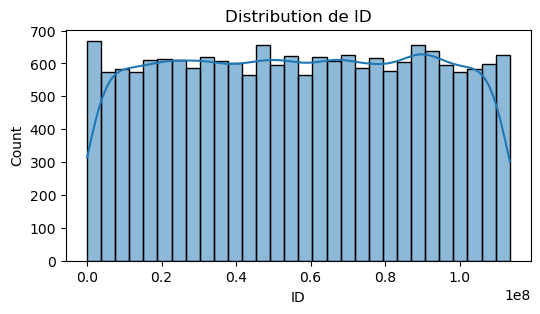

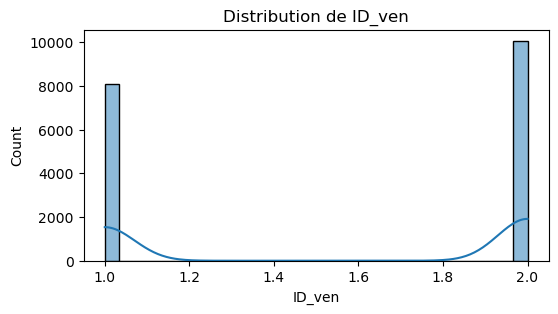

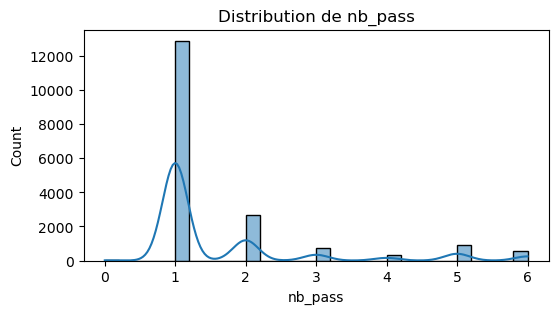

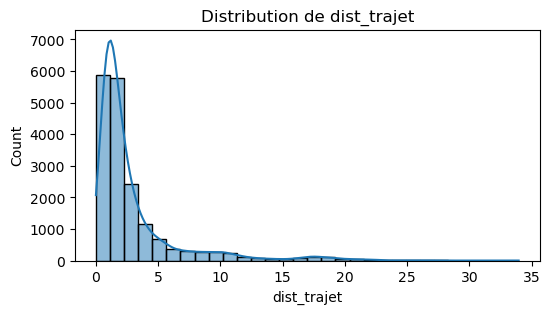

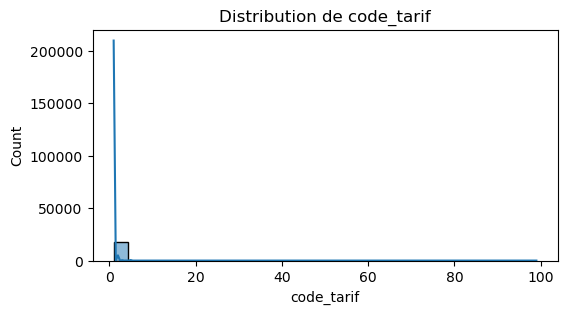

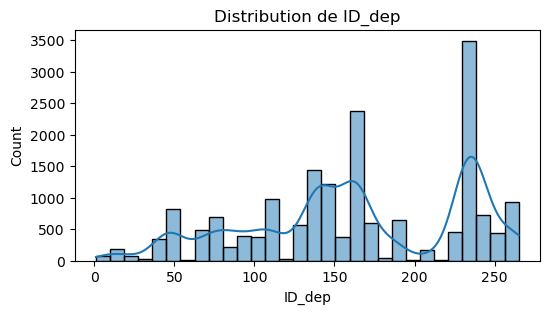

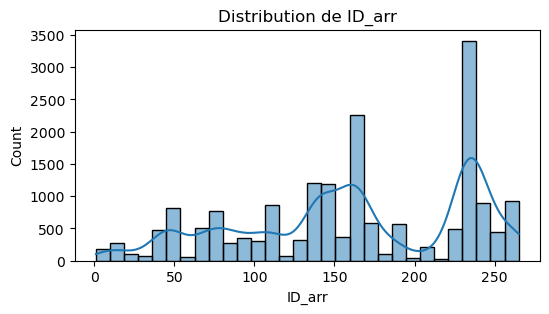

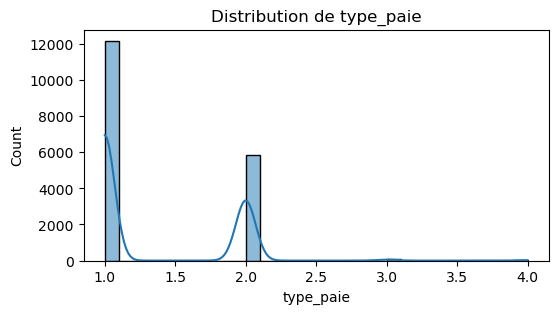

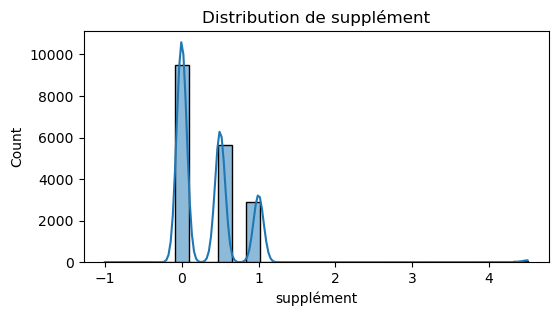

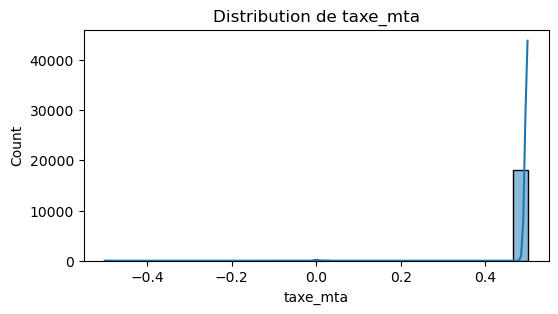

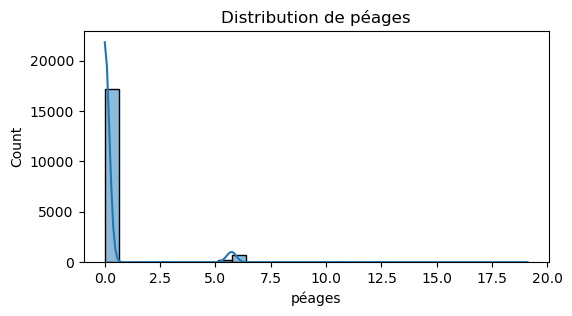

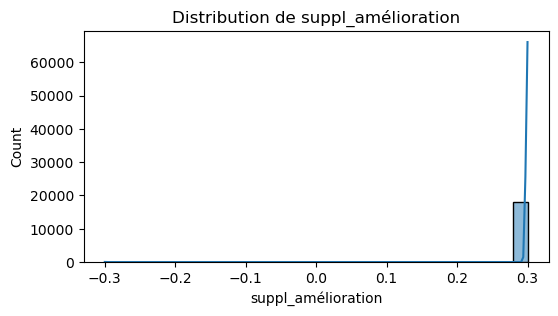

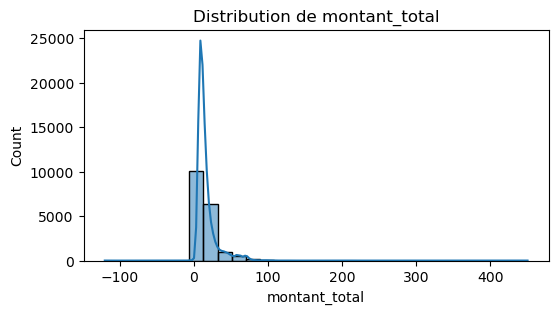

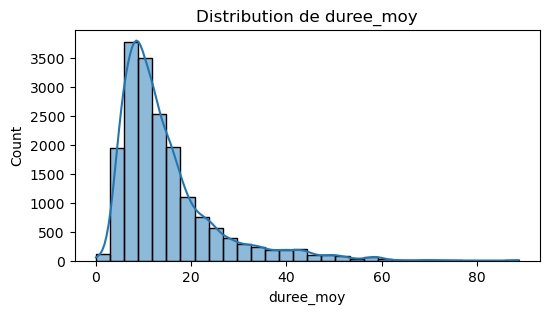

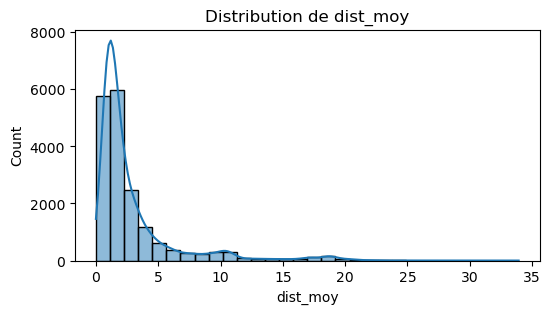

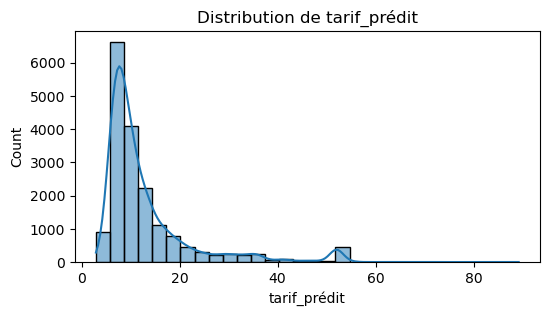

In [39]:
#Distributions des variables numériques:

for col in num_col:
    plt.figure(figsize=(6, 3))
    sns.histplot(X_train[col], kde=True, bins=30)
    plt.title(f'Distribution de {col}')
    plt.show()

**Interpretation:** Nos colonnes numérique ne suivent pas une distributioon gaussienne et on peut aussi remarquer que les données ne sont pas centrées ni reduites

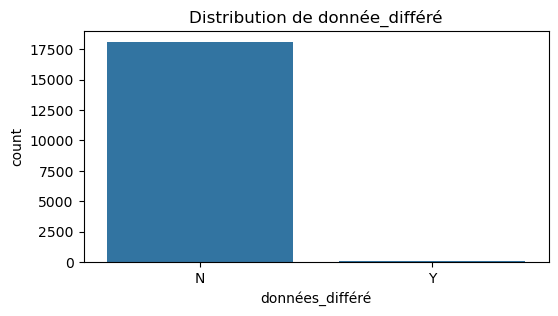

In [42]:

# Distribution des variables catégorielles:
plt.figure(figsize=(6, 3))

sns.countplot( data=X_train, x='données_différé') # Accès direct à la colonne via son nom

plt.title('Distribution de donnée_différé')
plt.show()  # Pour afficher le graphique


**Remarque:** On ne peut visualiser que cette variable de type 'object' car les autres sont des datetime et ne peuvent pas être visualisées

In [44]:

# Fonction pour détecter les outliers dans un DataFrame(Méthode d'interquantile)

def detect_outliers(X_train, columns):
    outliers_columns = []
    for col in columns:
        # Calcul de l'IQR pour chaque colonne
        Q1 = X_train[col].quantile(0.25)
        Q3 = X_train[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Définition des bornes
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Détection des outliers : valeurs en dehors des bornes
        if ((X_train[col] < lower_bound) | (X_train[col] > upper_bound)).any():
            outliers_columns.append(col)

    return outliers_columns

# Appliquer la fonction sur les colonnes numériques
outliers_columns = detect_outliers(X_train, num_col)

# Afficher les colonnes contenant des outliers
print("Colonnes avec des outliers :")
print(outliers_columns)


Colonnes avec des outliers :
['nb_pass', 'dist_trajet', 'code_tarif', 'type_paie', 'supplément', 'taxe_mta', 'péages', 'suppl_amélioration', 'montant_total', 'duree_moy', 'dist_moy', 'tarif_prédit']


**Interpretation:** Dans le préprocessing, on effectuera la standartisation et non la normalisation car les données contiennes assez de Outliers

C:\Users\User\AppData\Local\Temp\ipykernel_32800\1706580954.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_corr['client_généreux'] = y_train  # Ajout de y_train


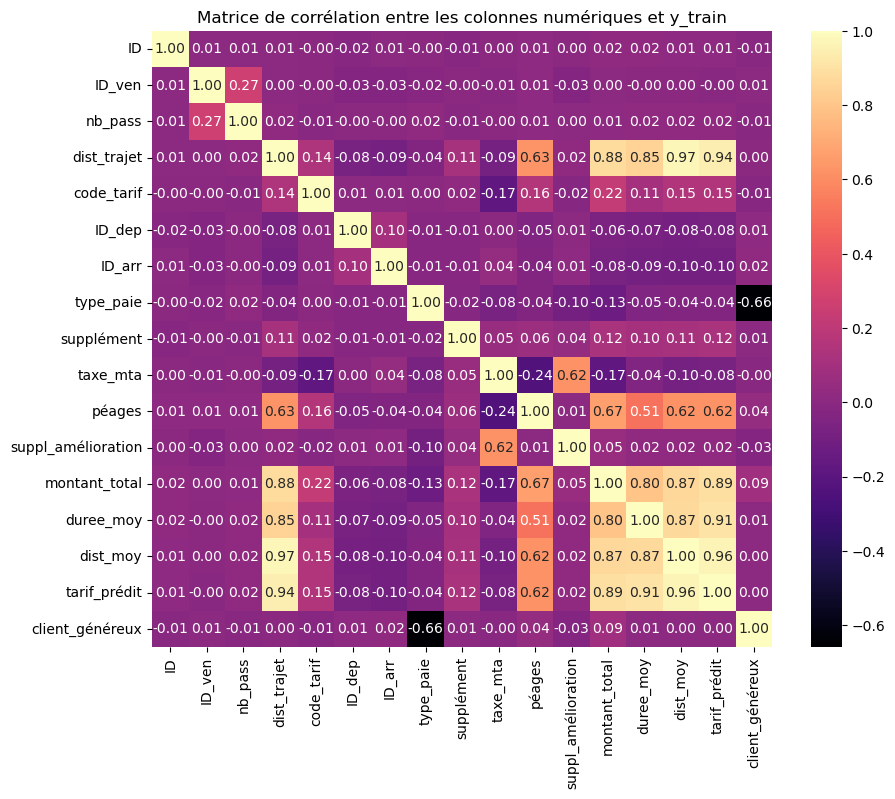

In [46]:
# Calculer la matrice de corrélation entre les colonnes numériques

# Ajouter y_train aux colonnes numériques pour la corrélation
X_train_corr = X_train[num_col]  # Copie des colonnes numériques
X_train_corr['client_généreux'] = y_train  # Ajout de y_train

# Calculer la matrice de corrélation
corr_matrix = X_train_corr.corr()

# Visualisation de la matrice de corrélation avec une heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='magma', fmt=".2f")
plt.title("Matrice de corrélation entre les colonnes numériques et y_train")
plt.show()


**Interpretations:**
- Le jeu de données contient plusieurs colonnes fortement correlées entre elles
- La target est assez liée à quelques features
- Le data contient énormemnt de colonnes inutiles

  Les cas mentionnés ci_dessus seront traité dans la partie préprocessing

### 2) Analyse Bivariée

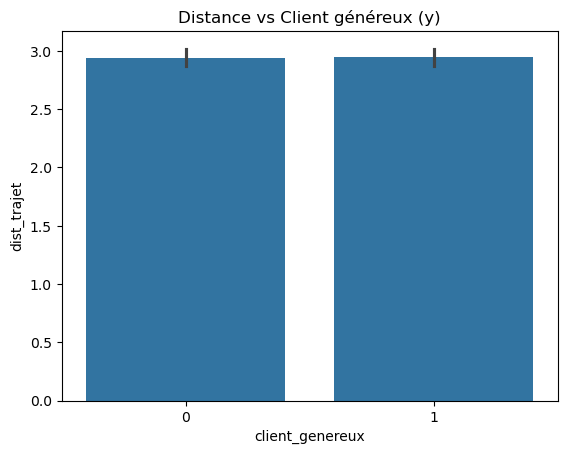

In [50]:
#Distribution de Distance_trajet selon y

sns.barplot(x=y, y=X_train["dist_trajet"])
plt.title("Distance vs Client généreux (y)")
plt.show()

**Interpretation:** Pas d'importance considéravle

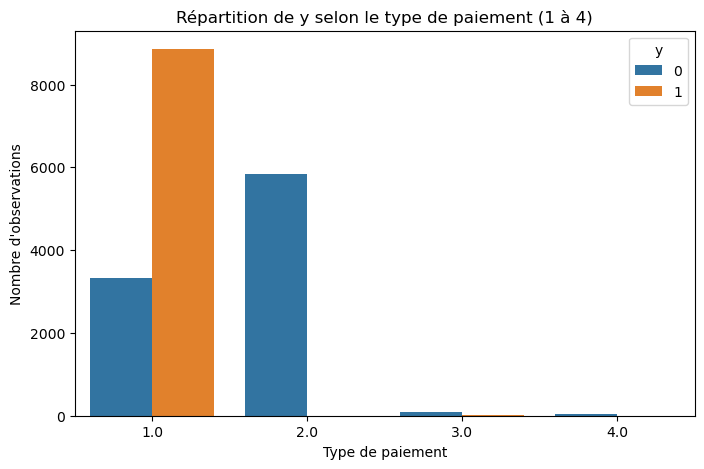

In [53]:
#Proportion de clients généreux selon le type de paie

plt.figure(figsize=(8, 5))
sns.countplot(x=X_train["type_paie"], hue=y)
plt.title("Répartition de y selon le type de paiement (1 à 4)")
plt.xlabel("Type de paiement")
plt.ylabel("Nombre d'observations")
plt.legend(title="y")


**Interpretation:** la majorité des clients paient avec les types 1 et 2, les clients généreux sont moins fréquents dans tous les cas.. Les types de paiement 3 et 4 ont très peu d'observations pour les deux catégories.



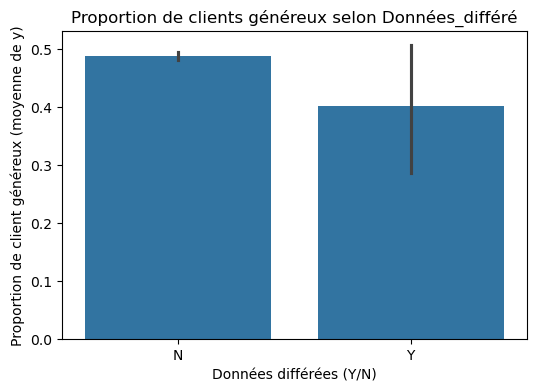

In [55]:
plt.figure(figsize=(6, 4))
sns.barplot(x=X_train["données_différé"], y=y)
plt.title("Proportion de clients généreux selon Données_différé")
plt.xlabel("Données différées (Y/N)")
plt.ylabel("Proportion de client généreux (moyenne de y)")
plt.show()

**Interpretation:** Les clients généreux sont proportionnellement plus nombreux lorsque les données ne sont pas différées ("N"). En revanche, la proportion diminue lorsque les données sont différées ("Y").



# <font color='brown'>IV. PREPROCESSING </font>

## 1. Netoyage de dataset

#### Gestion des valeurs manquantes

#### Traitement des outliers

In [61]:
def replace_outliers_with_mean(X_train):
    # Sélectionner uniquement les colonnes numériques
    numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
    
    for col in numeric_cols:
        Q1 = X_train[col].quantile(0.25)
        Q3 = X_train[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Calculer la moyenne des valeurs non outliers
        mask = (X_train[col] >= lower_bound) & (X_train[col] <= upper_bound)
        mean_val = X_train.loc[mask, col].mean()
        
        # Remplacer les outliers par la moyenne
        outlier_mask = (X_train[col] < lower_bound) | (X_train[col] > upper_bound)
        X_train.loc[outlier_mask, col] = mean_val
    
    return X_train

X_train = replace_outliers_with_mean(X_train)

C:\Users\User\AppData\Local\Temp\ipykernel_32800\3451963824.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '56767286.90412468' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train.loc[outlier_mask, col] = mean_val
C:\Users\User\AppData\Local\Temp\ipykernel_32800\3451963824.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.5548213007324192' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train.loc[outlier_mask, col] = mean_val
C:\Users\User\AppData\Local\Temp\ipykernel_32800\3451963824.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.2552124732497707' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_

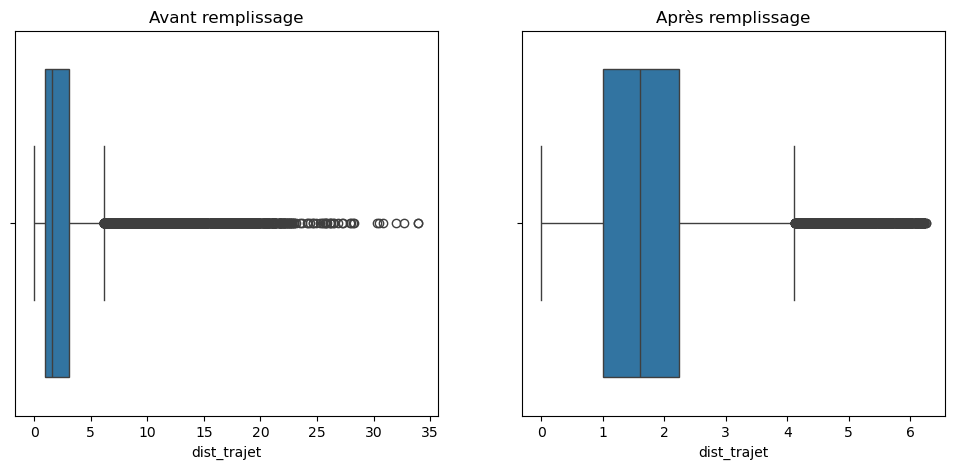

In [62]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df["dist_trajet"])
plt.title("Avant remplissage")

plt.subplot(1, 2, 2)
sns.boxplot(x=X_train["dist_trajet"])
plt.title("Après remplissage")

plt.show()


## 2. Encodage des variables catégorielles

In [64]:
#Encodage de seule colonne catégorielle restante
def encodage(X_train):
    X_train['données_différé'] = X_train['données_différé'].map({'Y': 1, 'N': 0})

    return X_train

X_train = encodage(X_train)

## 3. feature_engineering

In [66]:
def feature_engineering(X_train):
    """
    Calcule la durée du trajet en minutes et supprime les colonnes de dates originales.
    
    Paramètre:
    df (DataFrame): DataFrame contenant les colonnes dt_départ et dt_arrivée
    
    Retourne:
    DataFrame: Le même DataFrame avec la nouvelle colonne 'duree_trajet' 
              et sans les colonnes de dates originales
    """
    # Conversion et calcul de la durée
    X_train['duree_trajet'] = (pd.to_datetime(X_train['dt_arrivée']) - pd.to_datetime(X_train['dt_départ'])).dt.total_seconds() / 60
    
    # Suppression des colonnes de dates
    return X_train.drop(['dt_départ', 'dt_arrivée'], axis=1)

X_train = feature_engineering(X_train)


C:\Users\User\AppData\Local\Temp\ipykernel_32800\1950644231.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  X_train['duree_trajet'] = (pd.to_datetime(X_train['dt_arrivée']) - pd.to_datetime(X_train['dt_départ'])).dt.total_seconds() / 60
C:\Users\User\AppData\Local\Temp\ipykernel_32800\1950644231.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  X_train['duree_trajet'] = (pd.to_datetime(X_train['dt_arrivée']) - pd.to_datetime(X_train['dt_départ'])).dt.total_seconds() / 60


## 4. Sélection des features avec la matrice de correlation

Top features :
 type_paie        0.427845
montant_total    0.126371
duree_trajet     0.093771
dist_trajet      0.056219
ID               0.055785
tarif_prédit     0.044085
ID_arr           0.041844
duree_moy        0.041442
dist_moy         0.041084
ID_dep           0.037960
dtype: float64


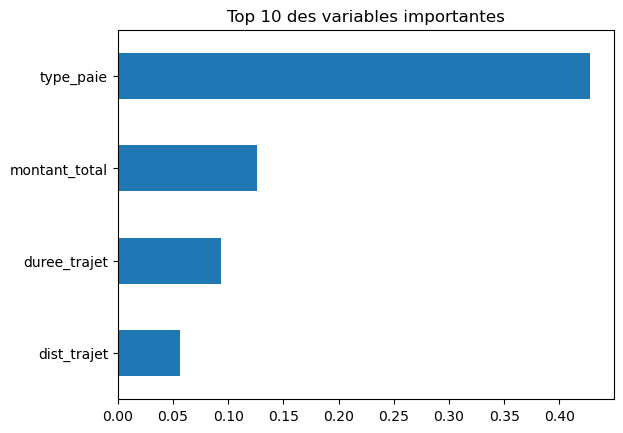

In [68]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# Entraînement rapide
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Importance des features
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

# Afficher les top N
print("Top features :\n", importances.head(10))

# Affichage graphique
importances.head(4).plot(kind='barh', title='Top 10 des variables importantes')
plt.gca().invert_yaxis()
plt.show()


In [69]:
topfeatures= ['type_paie', 'montant_total', 'duree_trajet', 'dist_trajet']

In [70]:
def featureselection(X_train):
    X_selected = X_train[topfeatures]

    return X_selected
X_train_selected = featureselection(X_train)

# <font color='brown'>VI. ENTRAINEMENT ET VALIDATION </font>

In [72]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Définir le modèle de base
rf = RandomForestClassifier(random_state=42)

# Définir la grille d'hyperparamètres
param_grid = {
    'n_estimators': [100, 200, 300, 400],              # Nombre d'arbres dans la forêt
    'max_depth': [None, 10, 20, 30, 52],             # Profondeur maximale de chaque arbre
    'min_samples_split': [25, 8, 15, 35],             # Nb min d’échantillons pour diviser un noeud
    'min_samples_leaf': [1, 2, 3, 4],              # Nb min d’échantillons dans une feuille
    'max_features': [None, 'log2']         # Méthode de sélection des features
}

# GridSearchCV avec validation croisée 5-fold
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',  # Ou f1, roc_auc selon le besoin
    n_jobs=-1,
    verbose=1
)

# Fit sur vos données (X, y)
grid_search.fit(X_train_selected, y_train)

# Afficher les meilleurs paramètres
print("Meilleurs paramètres trouvés :", grid_search.best_params_)


Fitting 5 folds for each of 640 candidates, totalling 3200 fits


C:\Users\User\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Meilleurs paramètres trouvés : {'max_depth': 20, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 200}


In [88]:
grid_search.best_score_

0.9294565155410398

In [90]:
best_rf = grid_search.best_estimator_


# <font color='brown'>V. Pretraitement du Test et Evaluation sur le Testset </font>

## 1. Prétraitement

In [94]:
# 1. (optionnel) Gérer les valeurs manquantes
# X_test = gest_val_manq(X_test)

# 2. Remplacer les outliers
X_test = replace_outliers_with_mean(X_test)

# 3. Feature engineering (création / transformation de variables)
X_test = feature_engineering(X_test)

# 4. Encodage (OneHot, LabelEncoding, etc.)
X_test = encodage(X_test)

# 5. Sélection de features (mêmes colonnes que sur train !)
X_test_selected = featureselection(X_test)

# 6. Normalisation / standardisation (si le modèle l’utilise)
# X_test_scaled = scale_features(X_test_selected)


C:\Users\User\AppData\Local\Temp\ipykernel_32800\3451963824.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '56723285.1784141' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train.loc[outlier_mask, col] = mean_val
C:\Users\User\AppData\Local\Temp\ipykernel_32800\3451963824.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.5618942731277532' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train.loc[outlier_mask, col] = mean_val
C:\Users\User\AppData\Local\Temp\ipykernel_32800\3451963824.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.2477177399457193' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_t

In [96]:
from sklearn.metrics import classification_report, confusion_matrix

# Prédictions sur le jeu de test
y_pred_test = best_rf.predict(X_test_selected)

# Évaluation
print(confusion_matrix(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test))


[[2039  258]
 [  87 2156]]
              precision    recall  f1-score   support

           0       0.96      0.89      0.92      2297
           1       0.89      0.96      0.93      2243

    accuracy                           0.92      4540
   macro avg       0.93      0.92      0.92      4540
weighted avg       0.93      0.92      0.92      4540



In [98]:
import joblib
joblib.dump(best_rf, "random_forest_best_model.pkl")


['random_forest_best_model.pkl']

In [110]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix

# Exemple de données (remplacer par tes propres données et prétraitement)
# X_train_selected, X_test, y_train, y_test doivent être définis

# Assurer que les colonnes sont les mêmes dans X_train_selected et X_test
X_test = X_test[X_train_selected.columns]  # Alignement des colonnes de X_test avec X_train_selected

# Transformer les features de manière cohérente
# (Assume les caractéristiques numériques et catégorielles)
numeric_features = ['feature1', 'feature2', 'feature3']  # Remplace par tes propres features numériques
categorical_features = ['feature4', 'feature5']         # Remplace par tes propres features catégorielles

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Remplacer les valeurs manquantes par la moyenne
    ('scaler', StandardScaler())  # Standardisation des données
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Remplacer les valeurs manquantes par la valeur la plus fréquente
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # Encodage des variables catégorielles
])

# Créer un préprocesseur pour appliquer les transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Créer un pipeline complet qui inclut le préprocesseur et le modèle
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Entraîner le pipeline sur les données d'entraînement
pipeline.fit(X_train_selected, y_train)

# Calcul des courbes d'apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    estimator=pipeline,
    X=X_train_selected, y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=5,  # Validation croisée à 5 plis
    scoring='accuracy',
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

# Moyennes et écarts-types pour les scores d'entraînement et de validation
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

train_std = np.std(train_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Calcul du score sur le jeu de test pour chaque taille d'échantillon d'entraînement
test_final_scores = []
for size in train_sizes:
    # On entraîne le modèle sur un sous-ensemble des données
    pipeline.fit(X_train_selected[:int(size * len(X_train_selected))], y_train[:int(size * len(y_train))])
    
    # Prédire sur X_test transformé avec le pipeline
    test_final_scores.append(pipeline.score(X_test, y_test))

# 📊 Affichage de la courbe d'apprentissage
plt.figure(figsize=(8, 6))

# Courbe d'entraînement (train)
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Entraînement')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')

# Courbe de validation croisée (cross-validation)
plt.plot(train_sizes, test_mean, 'o-', color='green', label='Validation croisée')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='green')

# Courbe de test (X_test)
plt.plot(train_sizes, test_final_scores, 'o-', color='red', label='Test (final)')

# Ajout des labels et légende
plt.title("Learning Curve - Random Forest")
plt.xlabel("Taille de l’échantillon d’entraînement")
plt.ylabel("Score de précision")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

# Évaluation des performances finales sur le jeu de test
y_pred = pipeline.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


ValueError: A given column is not a column of the dataframe